In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder.appName('EDA').getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 22:41:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.csv(
    "../Datasets/sinac2016DatosAbiertos.csv",
    header = True,
    inferSchema = True
)

In [4]:
df.show(2)

26/07/17 22:41:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------+--------------+--------------+---------------+----------+---------------------------+---------------------------+-----------------------+---------------+------------------------+--------------------------+--------------------------+----------------+---------------------+-------------------+--------------------+----------------------+----------------------+----------------+-------------------------+----------------------------------+-------------------------+-------------------------+---------------------+-------------------+------------------------+-------------------+-------------------------+------------------------+-------------+--------------------------+--------------+-------------+-------------------------+-----------------------------+------------------+--------------------+-------------+-------------+-------------------------+-----------------------+---------------+---------------------------+-----------------------+---------------------+--------------------+---

In [5]:
df.printSchema()

root
 |-- edo_captura: string (nullable = true)
 |-- edo_nac_madre: string (nullable = true)
 |-- mpo_nac_madre: string (nullable = true)
 |-- fecha_nac_madre: string (nullable = true)
 |-- edad_madre: integer (nullable = true)
 |-- madre_se_considera_indigena: string (nullable = true)
 |-- madre_habla_lengua_indigena: string (nullable = true)
 |-- lengua_indigena_hablada: string (nullable = true)
 |-- estado_conyugal: string (nullable = true)
 |-- entidad_residencia_madre: string (nullable = true)
 |-- municipio_residencia_madre: string (nullable = true)
 |-- localidad_residencia_madre: string (nullable = true)
 |-- numero_embarazos: integer (nullable = true)
 |-- hijos_nacidos_muertos: integer (nullable = true)
 |-- hijos_nacidos_vivos: integer (nullable = true)
 |-- hijos_sobrevivientes: integer (nullable = true)
 |-- el_hijo_anterior_nacio: string (nullable = true)
 |-- vive_aun_hijo_anterior: string (nullable = true)
 |-- orden_nacimiento: integer (nullable = true)
 |-- recibio_at

In [17]:
df.describe().show(vertical=True)

-RECORD 0--------------------------------------------------
 summary                            | count                
 edo_captura                        | 2080253              
 edo_nac_madre                      | 2080253              
 mpo_nac_madre                      | 2080253              
 fecha_nac_madre                    | 2080253              
 edad_madre                         | 2080253              
 madre_se_considera_indigena        | 2080253              
 madre_habla_lengua_indigena        | 2080253              
 lengua_indigena_hablada            | 2080253              
 estado_conyugal                    | 2080253              
 entidad_residencia_madre           | 2080253              
 municipio_residencia_madre         | 2080253              
 localidad_residencia_madre         | 2080253              
 numero_embarazos                   | 2080253              
 hijos_nacidos_muertos              | 2080253              
 hijos_nacidos_vivos                | 20

In [7]:
df.groupBy('edo_captura').count().show()

+--------------------+------+
|         edo_captura| count|
+--------------------+------+
|     BAJA CALIFORNIA| 52520|
|COAHUILA DE ZARAGOZA| 58901|
|             CHIAPAS| 87225|
|             DURANGO| 33167|
|            GUERRERO| 61276|
|           CHIHUAHUA| 61674|
|    DISTRITO FEDERAL|139731|
|          GUANAJUATO|114856|
|      AGUASCALIENTES| 28752|
| BAJA CALIFORNIA SUR| 11952|
|            CAMPECHE| 15145|
|              COLIMA| 12784|
|              MEXICO|261317|
| MICHOACAN DE OCAMPO| 85568|
|             NAYARIT| 17651|
|             HIDALGO| 47068|
|             MORELOS| 32749|
|              OAXACA| 71127|
|             JALISCO|141313|
|          NUEVO LEON| 93866|
+--------------------+------+
only showing top 20 rows


### Vizualizations

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Sample 10% of dataset for memory management
sample_df = df.sample(fraction=0.1, seed=42)

In [12]:
# Get only columns that are integers 
int_cols = [(i, col, dtype) for i, (col, dtype) in enumerate(df.dtypes) if dtype == 'int']
print(f'There are {len(int_cols)} in the dataframe')

for index, col_name, col_type in int_cols:
    print(f'|-- Index {index}: {col_name}')


There are 12 in the dataframe
|-- Index 4: edad_madre
|-- Index 12: numero_embarazos
|-- Index 13: hijos_nacidos_muertos
|-- Index 14: hijos_nacidos_vivos
|-- Index 15: hijos_sobrevivientes
|-- Index 18: orden_nacimiento
|-- Index 21: total_consultas_recibidas
|-- Index 30: semanas_gestacion_nac_vivo
|-- Index 31: talla_nac_vivo
|-- Index 32: peso_nac_vivo
|-- Index 33: valoracion_apgar_nac_vivo
|-- Index 34: valoracion_silverman_nac_vivo


In [21]:
# Summary Medians mins and maxs for features of interest
sample_df.describe().show()

+-------+--------------+--------------+-------------+---------------+------------------+---------------------------+---------------------------+-----------------------+---------------+------------------------+--------------------------+--------------------------+------------------+---------------------+-------------------+--------------------+----------------------+----------------------+------------------+-------------------------+----------------------------------+-------------------------+-------------------------+---------------------+--------------------+------------------------+-------------------+-------------------------+---------------+--------------------------+-----------------+------------------+-------------------------+-----------------------------+------------------+--------------------+-------------+-------------+-------------------------+-----------------------+------------------+---------------------------+-----------------------+---------------------+----------------

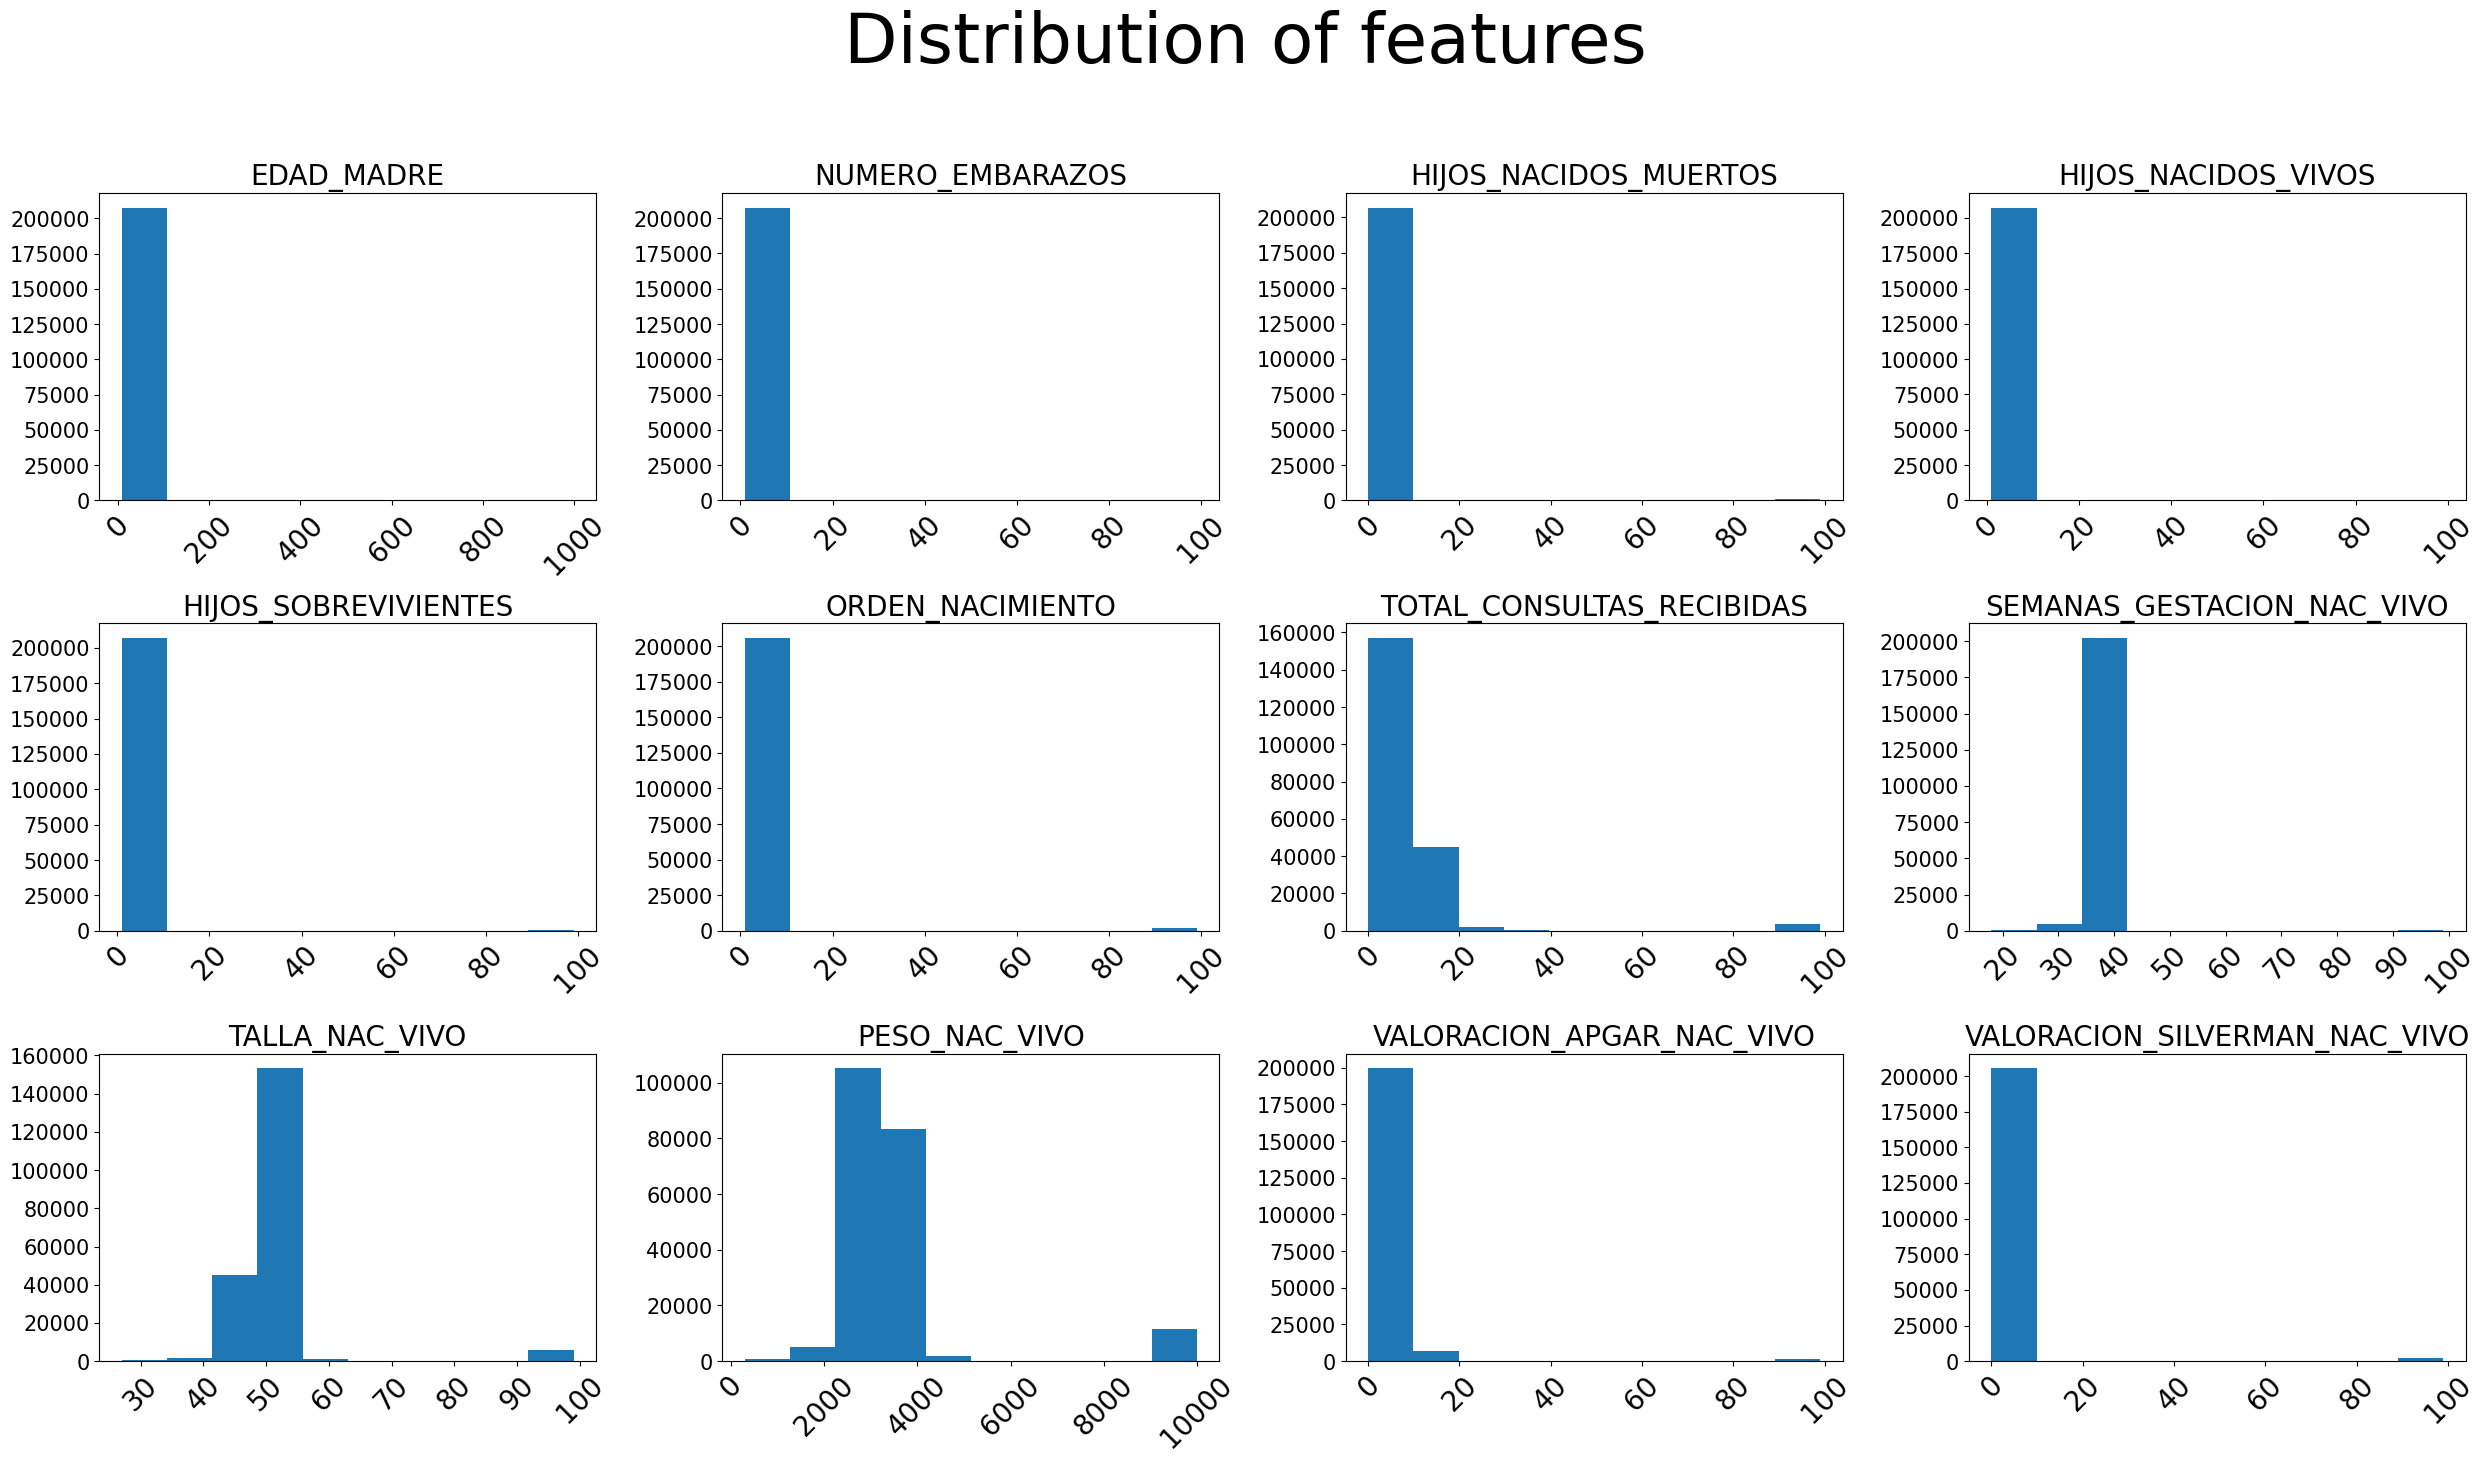

In [ ]:
pandas_df = sample_df.toPandas() # Making the pandas conversion before the loop improves speed
fig = plt.figure(figsize=(25,15))
st = fig.suptitle("Distribution of features", fontsize=50, verticalalignment="center")
for position, (_, col, _) in enumerate(int_cols, start=1):
    ax = fig.add_subplot(3,4, position)
    ax.hist(pandas_df[col])
    plt.grid(False)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=15)
    plt.title(col.upper(), fontsize=20)

plt.tight_layout()
st.set_y(0.95)

fig.subplots_adjust(top=0.85, hspace=0.4)
plt.show()
